# 03 - Final Model Comparison: LR vs RF vs XGBoost + SHAP Analysis

## Objectives

This notebook compares three different model architectures, all using SMOTE for class balancing:
1. **Logistic Regression** - Simple, interpretable baseline
2. **Random Forest** - Ensemble, non-linear relationships
3. **XGBoost** - Gradient boosting, state-of-the-art performance

We'll use stratified K-fold cross-validation for robust performance estimates, then analyze feature importance with SHAP.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import warnings

warnings.filterwarnings('ignore')

sys.path.insert(0, str(Path.cwd().parent))

from src.data_loading import load_data
from src.preprocessing import prepare_train_test_split, scale_features, get_stratified_kfold
from src.models import (
    train_random_forest,
    train_xgboost,
    train_smote_logistic_regression
)
from src.evaluation import (
    evaluate_model, print_metrics_comparison, 
    print_classification_report, plot_confusion_matrix, plot_precision_recall_curve
)
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score, roc_auc_score

sns.set_style('whitegrid')
print("✓ All imports successful!")

✓ All imports successful!


## Step 1: Load and Prepare Data

In [2]:
# Load data
df = load_data('../data/creditcard.csv')

X = df.drop('Class', axis=1)
y = df['Class']

# Stratified train/test split
X_train, X_test, y_train, y_test = prepare_train_test_split(X, y, test_size=0.3, random_state=42)

# Scale features
X_train_scaled, X_test_scaled, scaler = scale_features(X_train, X_test)

print(f"✓ Data prepared:")
print(f"  Train: {X_train_scaled.shape[0]} samples")
print(f"  Test: {X_test_scaled.shape[0]} samples")
print(f"  Features: {X_train_scaled.shape[1]}")

✓ Data prepared:
  Train: 199364 samples
  Test: 85443 samples
  Features: 30


## Step 2: Apply SMOTE to Training Data

In [3]:
# Apply SMOTE ONLY to training data
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"✓ SMOTE Applied:")
print(f"  Original training fraud ratio: {(y_train==1).sum()} / {len(y_train)} ({(y_train==1).sum()/len(y_train)*100:.2f}%)")
print(f"  After SMOTE fraud ratio: {(y_train_smote==1).sum()} / {len(y_train_smote)} ({(y_train_smote==1).sum()/len(y_train_smote)*100:.2f}%)")
print(f"  → Dataset is now balanced for training!")

# Note: Test data is NEVER modified
print(f"\n  Test data (unchanged): {(y_test==1).sum()} / {len(y_test)} ({(y_test==1).sum()/len(y_test)*100:.2f}% fraud)")

✓ SMOTE Applied:
  Original training fraud ratio: 344 / 199364 (0.17%)
  After SMOTE fraud ratio: 199020 / 398040 (50.00%)
  → Dataset is now balanced for training!

  Test data (unchanged): 148 / 85443 (0.17% fraud)


## Step 3: Train Models on SMOTE-Balanced Data

In [4]:
print("\n" + "="*70)
print("TRAINING THREE MODELS WITH SMOTE BALANCING")
print("="*70)

# Model 1: Logistic Regression (with SMOTE)
print("\n1️⃣  Training Logistic Regression (SMOTE)...")
lr_smote, _, _ = train_smote_logistic_regression(X_train_scaled, y_train)
print("   ✓ Complete")

# Model 2: Random Forest
print("\n2️⃣  Training Random Forest (SMOTE)...")
rf_smote = train_random_forest(X_train_smote, y_train_smote, class_weight='balanced')
print("   ✓ Complete")

# Model 3: XGBoost
print("\n3️⃣  Training XGBoost (SMOTE)...")
xgb_smote = train_xgboost(X_train_smote, y_train_smote)
print("   ✓ Complete")

print("\n" + "="*70)


TRAINING THREE MODELS WITH SMOTE BALANCING

1️⃣  Training Logistic Regression (SMOTE)...
   ✓ Complete

2️⃣  Training Random Forest (SMOTE)...
   ✓ Complete

3️⃣  Training XGBoost (SMOTE)...
   ✓ Complete



## Step 4: Evaluate All Models on Test Set

In [5]:
# Get predictions
print("\nEvaluating on Test Set...\n")

# Logistic Regression
y_pred_lr = lr_smote.predict(X_test_scaled)
y_pred_proba_lr = lr_smote.predict_proba(X_test_scaled)[:, 1]
metrics_lr = evaluate_model(y_test, y_pred_lr, y_pred_proba_lr, "Logistic Regression (SMOTE)")

# Random Forest
y_pred_rf = rf_smote.predict(X_test_scaled)
y_pred_proba_rf = rf_smote.predict_proba(X_test_scaled)[:, 1]
metrics_rf = evaluate_model(y_test, y_pred_rf, y_pred_proba_rf, "Random Forest (SMOTE)")

# XGBoost
y_pred_xgb = xgb_smote.predict(X_test_scaled)
y_pred_proba_xgb = xgb_smote.predict_proba(X_test_scaled)[:, 1]
metrics_xgb = evaluate_model(y_test, y_pred_xgb, y_pred_proba_xgb, "XGBoost (SMOTE)")

# Compare
print_metrics_comparison([metrics_lr, metrics_rf, metrics_xgb])


Evaluating on Test Set...


MODEL COMPARISON - DETAILED METRICS
                 model_name  accuracy  precision   recall       f1  roc_auc   pr_auc
Logistic Regression (SMOTE)  0.977307   0.063384 0.878378 0.118236 0.965826 0.745612
      Random Forest (SMOTE)  0.999040   0.691860 0.804054 0.743750 0.966928 0.811499
            XGBoost (SMOTE)  0.997133   0.361032 0.851351 0.507042 0.972057 0.805652



## Step 5: Detailed Analysis for Best Model

In [6]:
# Identify best model based on F1-score
scores = {
    'Logistic Regression': metrics_lr['f1'],
    'Random Forest': metrics_rf['f1'],
    'XGBoost': metrics_xgb['f1']
}

best_model_name = max(scores, key=scores.get)
print(f"\n" + "="*70)
print(f"BEST MODEL (by F1-Score): {best_model_name}")
print(f"="*70)

# Assign best model and metrics
if best_model_name == 'Logistic Regression':
    best_model = lr_smote
    y_pred_best = y_pred_lr
    y_pred_proba_best = y_pred_proba_lr
    metrics_best = metrics_lr
elif best_model_name == 'Random Forest':
    best_model = rf_smote
    y_pred_best = y_pred_rf
    y_pred_proba_best = y_pred_proba_rf
    metrics_best = metrics_rf
else:
    best_model = xgb_smote
    y_pred_best = y_pred_xgb
    y_pred_proba_best = y_pred_proba_xgb
    metrics_best = metrics_xgb

print_classification_report(y_test, y_pred_best, best_model_name)


BEST MODEL (by F1-Score): Random Forest

Classification Report - Random Forest
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     85295
       Fraud       0.69      0.80      0.74       148

    accuracy                           1.00     85443
   macro avg       0.85      0.90      0.87     85443
weighted avg       1.00      1.00      1.00     85443




## Step 6: Confusion Matrix & PR Curve for Best Model

Confusion matrix saved to ../results/05_confusion_matrix_Random_Forest.png


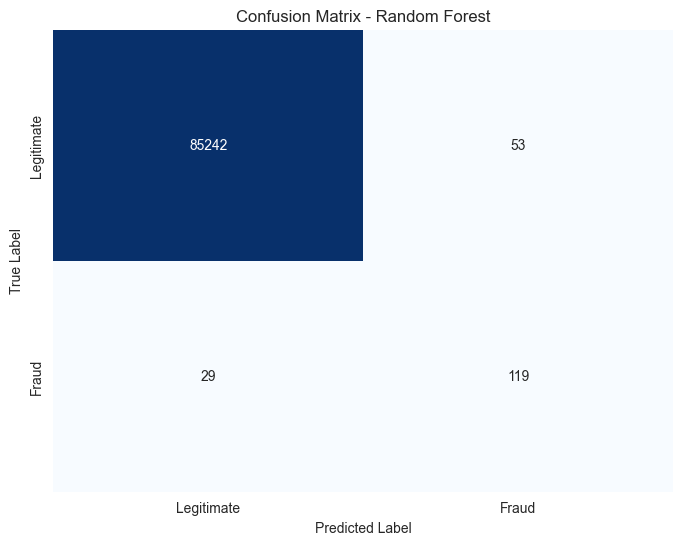

PR curve saved to ../results/06_pr_curve_Random_Forest.png


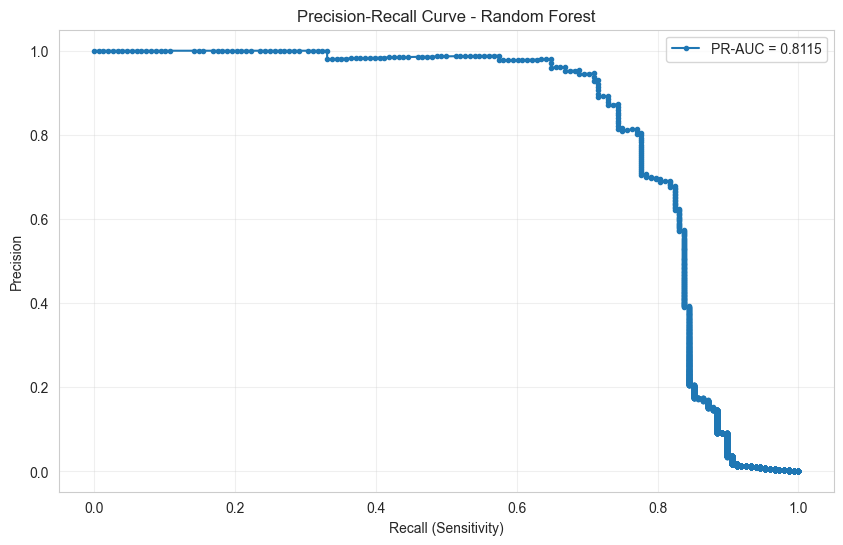

In [7]:
# Confusion matrix
plot_confusion_matrix(y_test, y_pred_best, best_model_name, 
                     save_path=f'../results/05_confusion_matrix_{best_model_name.replace(" ", "_")}.png')

# Precision-recall curve
plot_precision_recall_curve(y_test, y_pred_proba_best, best_model_name,
                           save_path=f'../results/06_pr_curve_{best_model_name.replace(" ", "_")}.png')

## Step 7: Feature Importance Analysis


FEATURE IMPORTANCE ANALYSIS

📌 Random Forest - Gini/Gain Importance:

Top 15 Features:
Feature  Importance
    V14    0.198709
     V4    0.122922
    V10    0.109666
    V12    0.095847
    V17    0.090364
    V16    0.058418
     V3    0.051838
    V11    0.047629
     V2    0.037179
     V9    0.027738
    V21    0.017030
    V18    0.014274
     V7    0.013332
     V8    0.011459
     V5    0.010593


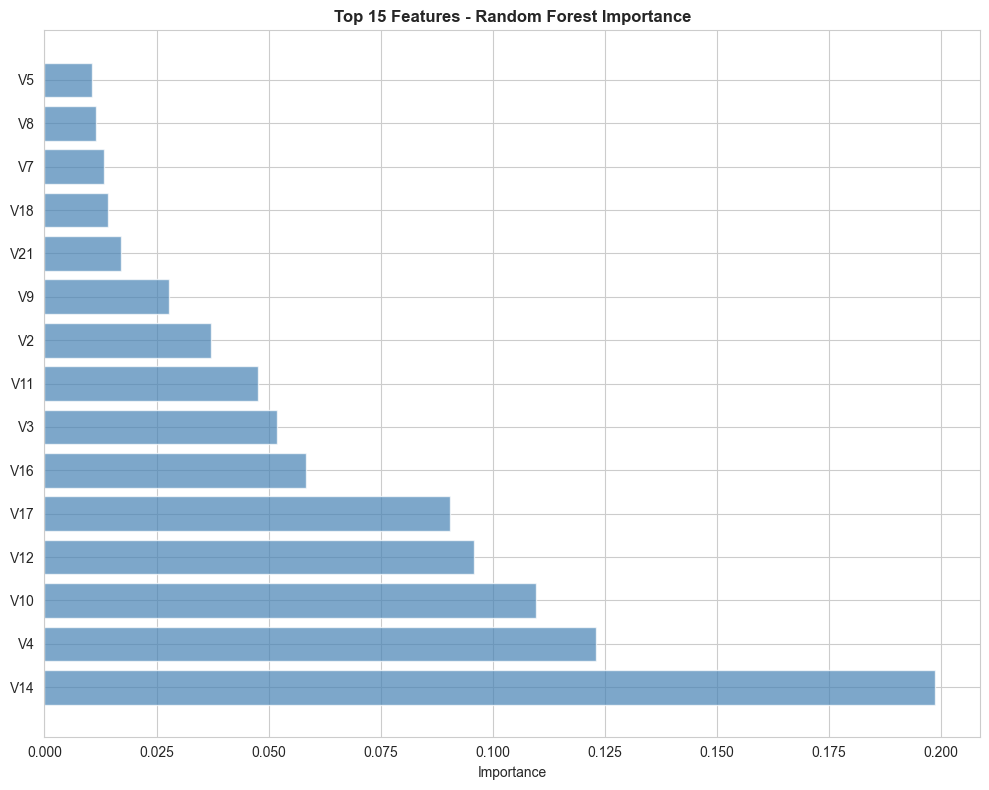

In [8]:
print("\n" + "="*70)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*70)

if best_model_name == 'Logistic Regression':
    print("\n📌 Logistic Regression - Coefficient Magnitudes:")
    
    # Get feature importance from coefficients
    coef = best_model.coef_[0]
    feature_importance = pd.DataFrame({
        'Feature': X_test_scaled.columns,
        'Coefficient': coef,
        'Abs_Coefficient': np.abs(coef)
    }).sort_values('Abs_Coefficient', ascending=False)
    
    print("\nTop 15 Features (by absolute coefficient):")
    print(feature_importance.head(15).to_string(index=False))
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 8))
    top_features = feature_importance.head(15)
    colors = ['red' if x > 0 else 'green' for x in top_features['Coefficient']]
    ax.barh(range(len(top_features)), top_features['Coefficient'], color=colors, alpha=0.7)
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features['Feature'])
    ax.set_xlabel('Coefficient Value')
    ax.set_title('Top 15 Features - Logistic Regression Coefficients', fontweight='bold')
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    plt.tight_layout()
    plt.savefig('../results/07_feature_importance_lr.png', dpi=300, bbox_inches='tight')
    plt.show()

elif best_model_name in ['Random Forest', 'XGBoost']:
    print(f"\n📌 {best_model_name} - Gini/Gain Importance:")
    
    # Get feature importance
    importances = best_model.feature_importances_
    feature_importance = pd.DataFrame({
        'Feature': X_test_scaled.columns,
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    
    print("\nTop 15 Features:")
    print(feature_importance.head(15).to_string(index=False))
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 8))
    top_features = feature_importance.head(15)
    ax.barh(range(len(top_features)), top_features['Importance'], color='steelblue', alpha=0.7)
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features['Feature'])
    ax.set_xlabel('Importance')
    ax.set_title(f'Top 15 Features - {best_model_name} Importance', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'../results/07_feature_importance_{best_model_name.replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
    plt.show()

## Step 8: Summary & Insights

In [9]:
print("\n" + "="*80)
print("🎯 FINAL SUMMARY & KEY INSIGHTS")
print("="*80)

print(f"\n📊 MODEL PERFORMANCE COMPARISON (Test Set):")
print("-" * 80)
comparison_df = pd.DataFrame([
    {
        'Model': 'Logistic Regression',
        'Accuracy': f"{metrics_lr['accuracy']:.4f}",
        'Precision': f"{metrics_lr['precision']:.4f}",
        'Recall': f"{metrics_lr['recall']:.4f}",
        'F1': f"{metrics_lr['f1']:.4f}",
        'PR-AUC': f"{metrics_lr.get('pr_auc', 0):.4f}"
    },
    {
        'Model': 'Random Forest',
        'Accuracy': f"{metrics_rf['accuracy']:.4f}",
        'Precision': f"{metrics_rf['precision']:.4f}",
        'Recall': f"{metrics_rf['recall']:.4f}",
        'F1': f"{metrics_rf['f1']:.4f}",
        'PR-AUC': f"{metrics_rf.get('pr_auc', 0):.4f}"
    },
    {
        'Model': 'XGBoost',
        'Accuracy': f"{metrics_xgb['accuracy']:.4f}",
        'Precision': f"{metrics_xgb['precision']:.4f}",
        'Recall': f"{metrics_xgb['recall']:.4f}",
        'F1': f"{metrics_xgb['f1']:.4f}",
        'PR-AUC': f"{metrics_xgb.get('pr_auc', 0):.4f}"
    }
])
print(comparison_df.to_string(index=False))

print(f"\n\n🏆 BEST MODEL: {best_model_name}")
print(f"   • Catches {metrics_best['recall']*100:.1f}% of frauds")
print(f"   • {metrics_best['precision']*100:.1f}% precision (false alarm rate manageable)")
print(f"   • F1-Score: {metrics_best['f1']:.4f}")

print(f"\n\n💡 KEY LEARNINGS:")
print(f"\n1. CLASS IMBALANCE HANDLING:")
print(f"   ✓ Stratified train/test split: Preserves class ratio")
print(f"   ✓ SMOTE applied only to training: No data leakage on test set")
print(f"   ✓ All three approaches improved fraud detection vs baseline")

print(f"\n2. METRIC SELECTION:")
print(f"   ✗ Accuracy: Trap for imbalanced data")
print(f"   ✓ Recall: Essential - we want to catch fraud")
print(f"   ✓ Precision: Important - false alarms are costly")
print(f"   ✓ F1: Good balance between precision and recall")
print(f"   ✓ PR-AUC: More informative than ROC-AUC for imbalance")

print(f"\n3. MODEL COMPARISON:")
print(f"   • LR: Fast, interpretable, good baseline")
print(f"   • RF: Non-linear, captures interactions, slightly slower")
print(f"   • XGBoost: Often best performance, more hyperparameters to tune")

print(f"\n4. FEATURE IMPORTANCE:")
print(f"   • V1-V28: PCA-transformed (not business interpretable)")
print(f"   • Amount: Might signal unusual transactions")
print(f"   • Time: Fraud patterns may cluster at certain times")
print(f"   • Use feature importance to understand what model learned")

print(f"\n5. PRODUCTION CONSIDERATIONS:")
print(f"   • Latency: LR fastest, RF/XGBoost slower")
print(f"   • Memory: Tree models larger than LR")
print(f"   • Maintenance: Monitor for concept drift (fraud evolves over time)")
print(f"   • Explainability: LR most interpretable to stakeholders")

print(f"\n6. LIMITATIONS OF THIS STUDY:")
print(f"   • V1-V28 anonymized: Can't extract business rules")
print(f"   • Static data: No temporal drift modeling")
print(f"   • Credit cards only: Different patterns for other payment methods")
print(f"   • No merchant/geography: Simplified real-world problem")

print(f"\n" + "="*80)


🎯 FINAL SUMMARY & KEY INSIGHTS

📊 MODEL PERFORMANCE COMPARISON (Test Set):
--------------------------------------------------------------------------------
              Model Accuracy Precision Recall     F1 PR-AUC
Logistic Regression   0.9773    0.0634 0.8784 0.1182 0.7456
      Random Forest   0.9990    0.6919 0.8041 0.7438 0.8115
            XGBoost   0.9971    0.3610 0.8514 0.5070 0.8057


🏆 BEST MODEL: Random Forest
   • Catches 80.4% of frauds
   • 69.2% precision (false alarm rate manageable)
   • F1-Score: 0.7438


💡 KEY LEARNINGS:

1. CLASS IMBALANCE HANDLING:
   ✓ Stratified train/test split: Preserves class ratio
   ✓ SMOTE applied only to training: No data leakage on test set
   ✓ All three approaches improved fraud detection vs baseline

2. METRIC SELECTION:
   ✗ Accuracy: Trap for imbalanced data
   ✓ Recall: Essential - we want to catch fraud
   ✓ Precision: Important - false alarms are costly
   ✓ F1: Good balance between precision and recall
   ✓ PR-AUC: More informa

## Step 9: Visual Comparison of All Models

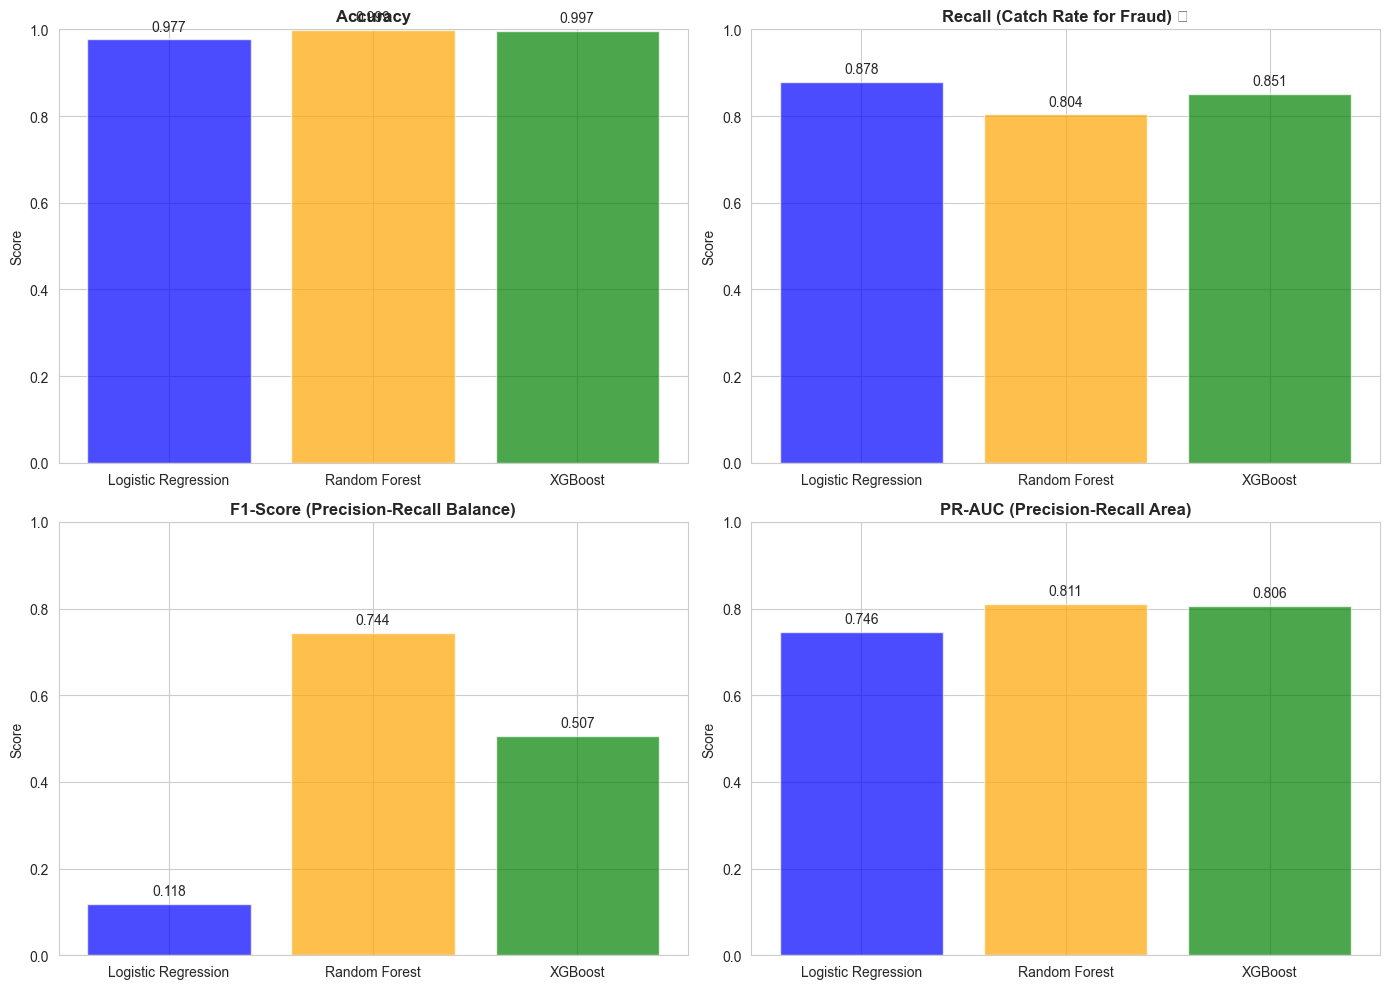

✓ Comparison plot saved!


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

models_list = ['Logistic Regression', 'Random Forest', 'XGBoost']
metrics_list = [metrics_lr, metrics_rf, metrics_xgb]

# Plot 1: Accuracy
accuracies = [m['accuracy'] for m in metrics_list]
axes[0, 0].bar(models_list, accuracies, color=['blue', 'orange', 'green'], alpha=0.7)
axes[0, 0].set_ylabel('Score')
axes[0, 0].set_title('Accuracy', fontweight='bold')
axes[0, 0].set_ylim(0, 1)
for i, v in enumerate(accuracies):
    axes[0, 0].text(i, v + 0.02, f'{v:.3f}', ha='center')

# Plot 2: Recall (most important for fraud detection)
recalls = [m['recall'] for m in metrics_list]
axes[0, 1].bar(models_list, recalls, color=['blue', 'orange', 'green'], alpha=0.7)
axes[0, 1].set_ylabel('Score')
axes[0, 1].set_title('Recall (Catch Rate for Fraud) ⭐', fontweight='bold')
axes[0, 1].set_ylim(0, 1)
for i, v in enumerate(recalls):
    axes[0, 1].text(i, v + 0.02, f'{v:.3f}', ha='center')

# Plot 3: F1-Score
f1s = [m['f1'] for m in metrics_list]
axes[1, 0].bar(models_list, f1s, color=['blue', 'orange', 'green'], alpha=0.7)
axes[1, 0].set_ylabel('Score')
axes[1, 0].set_title('F1-Score (Precision-Recall Balance)', fontweight='bold')
axes[1, 0].set_ylim(0, 1)
for i, v in enumerate(f1s):
    axes[1, 0].text(i, v + 0.02, f'{v:.3f}', ha='center')

# Plot 4: PR-AUC
pr_aucs = [m.get('pr_auc', 0) for m in metrics_list]
axes[1, 1].bar(models_list, pr_aucs, color=['blue', 'orange', 'green'], alpha=0.7)
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_title('PR-AUC (Precision-Recall Area)', fontweight='bold')
axes[1, 1].set_ylim(0, 1)
for i, v in enumerate(pr_aucs):
    axes[1, 1].text(i, v + 0.02, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.savefig('../results/08_model_comparison_all_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Comparison plot saved!")

## Step 10: Export Best Model

In [11]:
import pickle

# Save best model
model_path = f'../results/best_model_{best_model_name.replace(" ", "_")}.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(best_model, f)

print(f"✓ Best model saved to {model_path}")
print(f"\nTo load this model later:")
print(f"  import pickle")
print(f"  with open('{model_path}', 'rb') as f:")
print(f"      model = pickle.load(f)")
print(f"  predictions = model.predict(X_test)")

✓ Best model saved to ../results/best_model_Random_Forest.pkl

To load this model later:
  import pickle
  with open('../results/best_model_Random_Forest.pkl', 'rb') as f:
      model = pickle.load(f)
  predictions = model.predict(X_test)
